<a href="https://colab.research.google.com/github/Sameh184/Diabetes_repo/blob/main/Diabetes_Prediction_Model_MI_Binned_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#Reading the data and inspecting it
import pandas as pd
dataset = pd.read_csv('/content/Diabetes Dataset (1).csv')
print(dataset.head())
print(dataset.info())
print(dataset.describe())
print(dataset['CLASS'].value_counts())
print(dataset['Gender'].value_counts())



#Gender needs to be encoded along with the target variable.


#The Yes values in the data set are way more than the no and the P meaning that we have about an 80-20 imbalance of data which could cause the model to be biased.

    ID  No_Pation Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL  \
0  502      17975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
1  735      34221      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6   
2  420      47975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
3  680      87656      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
4  504      34223      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4   

    BMI CLASS  
0  24.0     N  
1  23.0     N  
2  24.0     N  
3  24.0     N  
4  21.0     N  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c     

In [20]:
#Data cleaning

dataset["CLASS"] = dataset["CLASS"].replace("Y " , "Y")
dataset["CLASS"] = dataset["CLASS"].replace("N " , "N")
dataset["Gender"] = dataset["Gender"].replace("f" , "F")
print(dataset['CLASS'].value_counts())
print(dataset['Gender'].value_counts())


#Removing useless columns
dataset = dataset.drop(axis= 1 , columns=["ID" , "No_Pation" ])

print(dataset.head())
print(dataset.shape)

#Checking if there are any missing values
print(dataset.isna().sum())


CLASS
Y    844
N    103
P     53
Name: count, dtype: int64
Gender
M    565
F    435
Name: count, dtype: int64
  Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI CLASS
0      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
1      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0     N
2      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
3      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
4      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0     N
(1000, 12)
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [21]:
print("--- Outlier Report ---")

numerical_columns_to_check = ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]

cleaned_dataset = dataset.copy()

for col in numerical_columns_to_check:
    Q1 = cleaned_dataset[col].quantile(0.25)
    Q3 = cleaned_dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers_low = (cleaned_dataset[col] < lower_bound).sum()
    outliers_high = (cleaned_dataset[col] > upper_bound).sum()
    total_outliers = outliers_low + outliers_high

    print(f"Column: {col}")
    print(f"  Bounds:    [{lower_bound:.2f} , {upper_bound:.2f}]")
    print(f"  Outliers:  {total_outliers} (Low: {outliers_low}, High: {outliers_high})\n")
    # removing outliers
    dataset = cleaned_dataset[
        (cleaned_dataset[col] >= lower_bound) &
        (cleaned_dataset[col] <= upper_bound)
    ]
    # FIX: carry the filtered rows forward so outlier removal accumulates
    # across columns instead of only reflecting the last column processed.
    cleaned_dataset = dataset.copy()

print(f"Final dataset shape after cumulative outlier removal: {dataset.shape}")

--- Outlier Report ---
Column: AGE
  Bounds:    [39.00 , 71.00]
  Outliers:  98 (Low: 79, High: 19)

Column: Urea
  Bounds:    [0.70 , 8.70]
  Outliers:  59 (Low: 1, High: 58)

Column: Cr
  Bounds:    [8.50 , 108.50]
  Outliers:  10 (Low: 0, High: 10)

Column: HbA1c
  Bounds:    [1.55 , 15.55]
  Outliers:  6 (Low: 4, High: 2)

Column: Chol
  Bounds:    [1.60 , 8.00]
  Outliers:  24 (Low: 3, High: 21)

Column: TG
  Bounds:    [-0.60 , 5.00]
  Outliers:  40 (Low: 0, High: 40)

Column: HDL
  Bounds:    [0.30 , 1.90]
  Outliers:  40 (Low: 1, High: 39)

Column: LDL
  Bounds:    [-0.45 , 5.55]
  Outliers:  3 (Low: 0, High: 3)

Column: VLDL
  Bounds:    [-0.35 , 2.45]
  Outliers:  42 (Low: 0, High: 42)

Column: BMI
  Bounds:    [15.50 , 43.50]
  Outliers:  0 (Low: 0, High: 0)

Final dataset shape after cumulative outlier removal: (678, 12)


In [22]:
#Feature transformation
dataset['CLASS'] = dataset['CLASS'].astype('category').cat.codes
dataset['Gender'] = dataset['Gender'].astype('category').cat.codes


dataset.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
6,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0
7,1,48,4.7,47,4.0,2.9,0.8,0.9,1.6,0.4,24.0,0
13,0,45,4.6,54,5.1,4.2,1.7,1.2,2.2,0.8,23.0,0
14,0,50,3.5,39,4.0,4.0,1.5,1.2,2.2,0.7,24.0,0


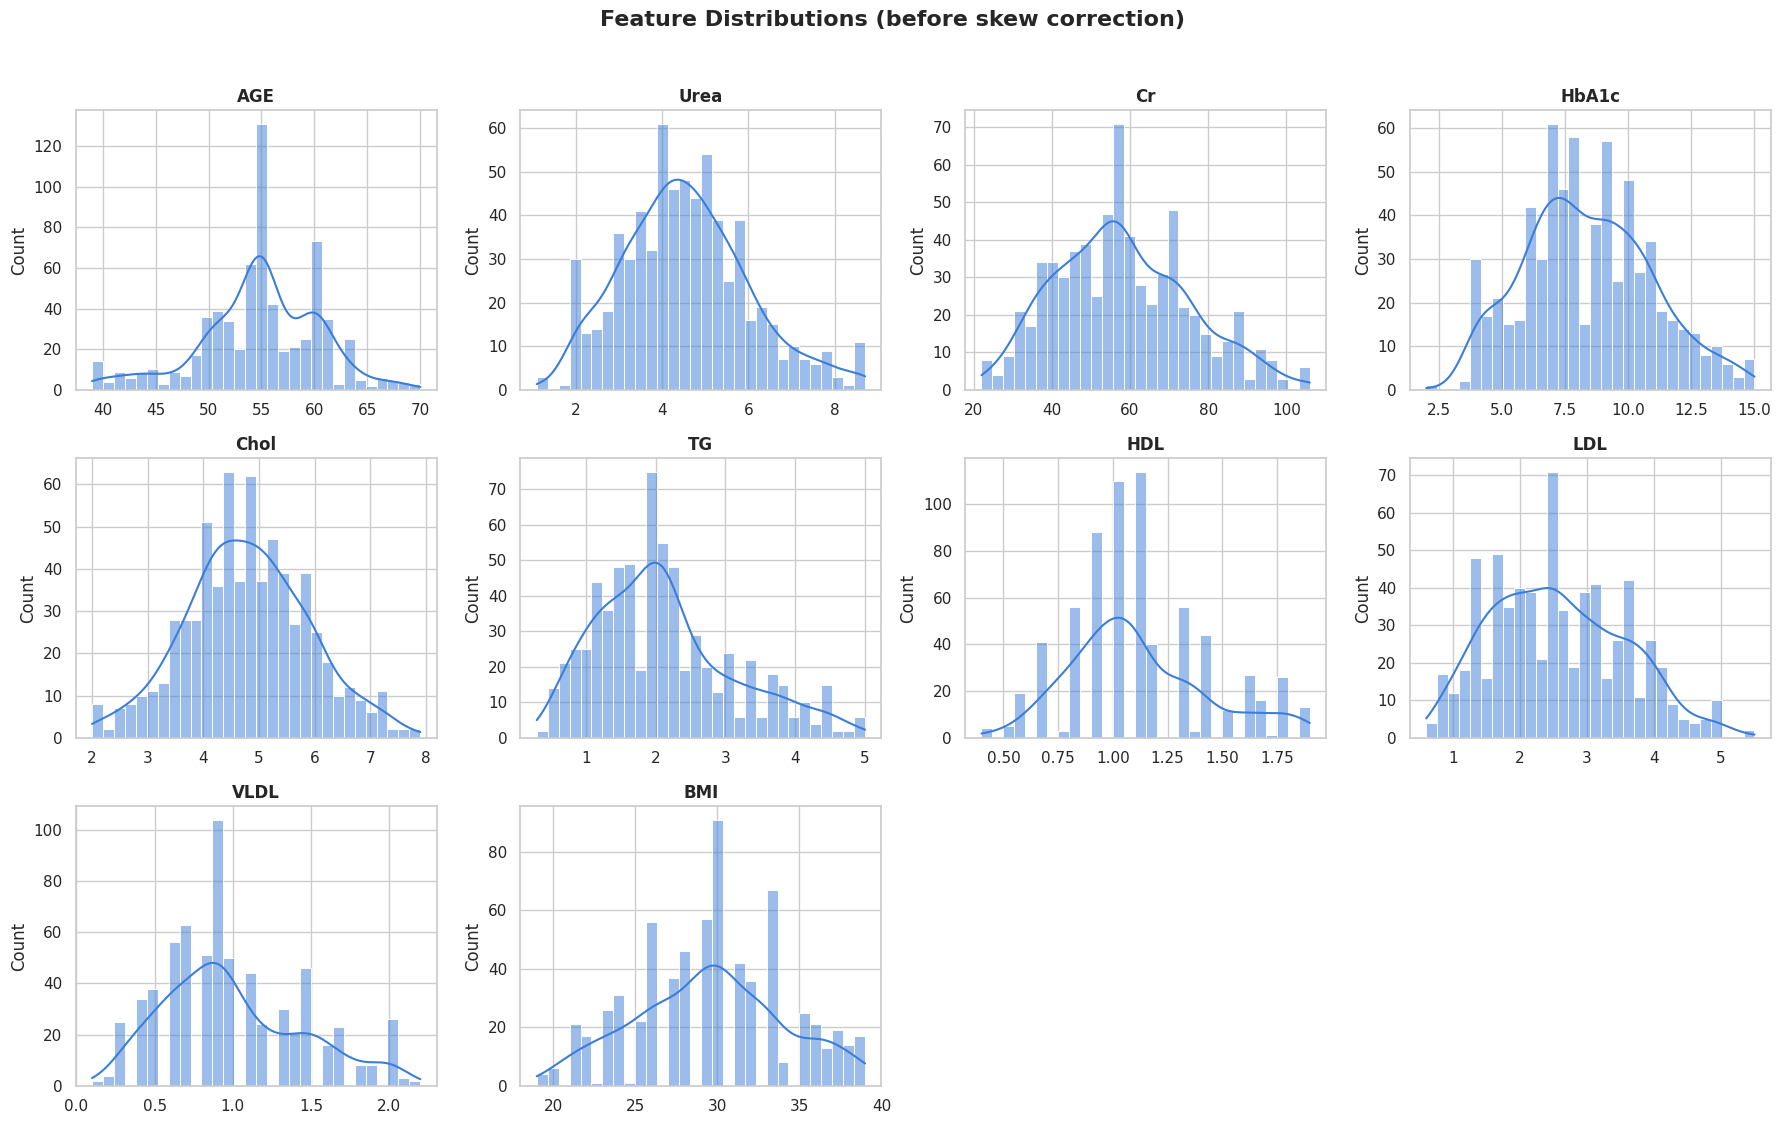

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [23]:
#Plot histograms to show skewness
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")

numerical_columns = dataset.select_dtypes(exclude="object")
numerical_columns = numerical_columns.drop(axis=1 , columns=["Gender" , "CLASS"])

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns.columns):
    sns.histplot(numerical_columns[col], bins=30, kde=True, color="#3b7dd8", ax=ax, edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
for ax in axes[len(numerical_columns.columns):]:
    ax.axis("off")
fig.suptitle("Feature Distributions (before skew correction)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(dataset.isna().sum())

#The following columns are skewed => Urea , Cr , TG , VLDL , HDL , LDL

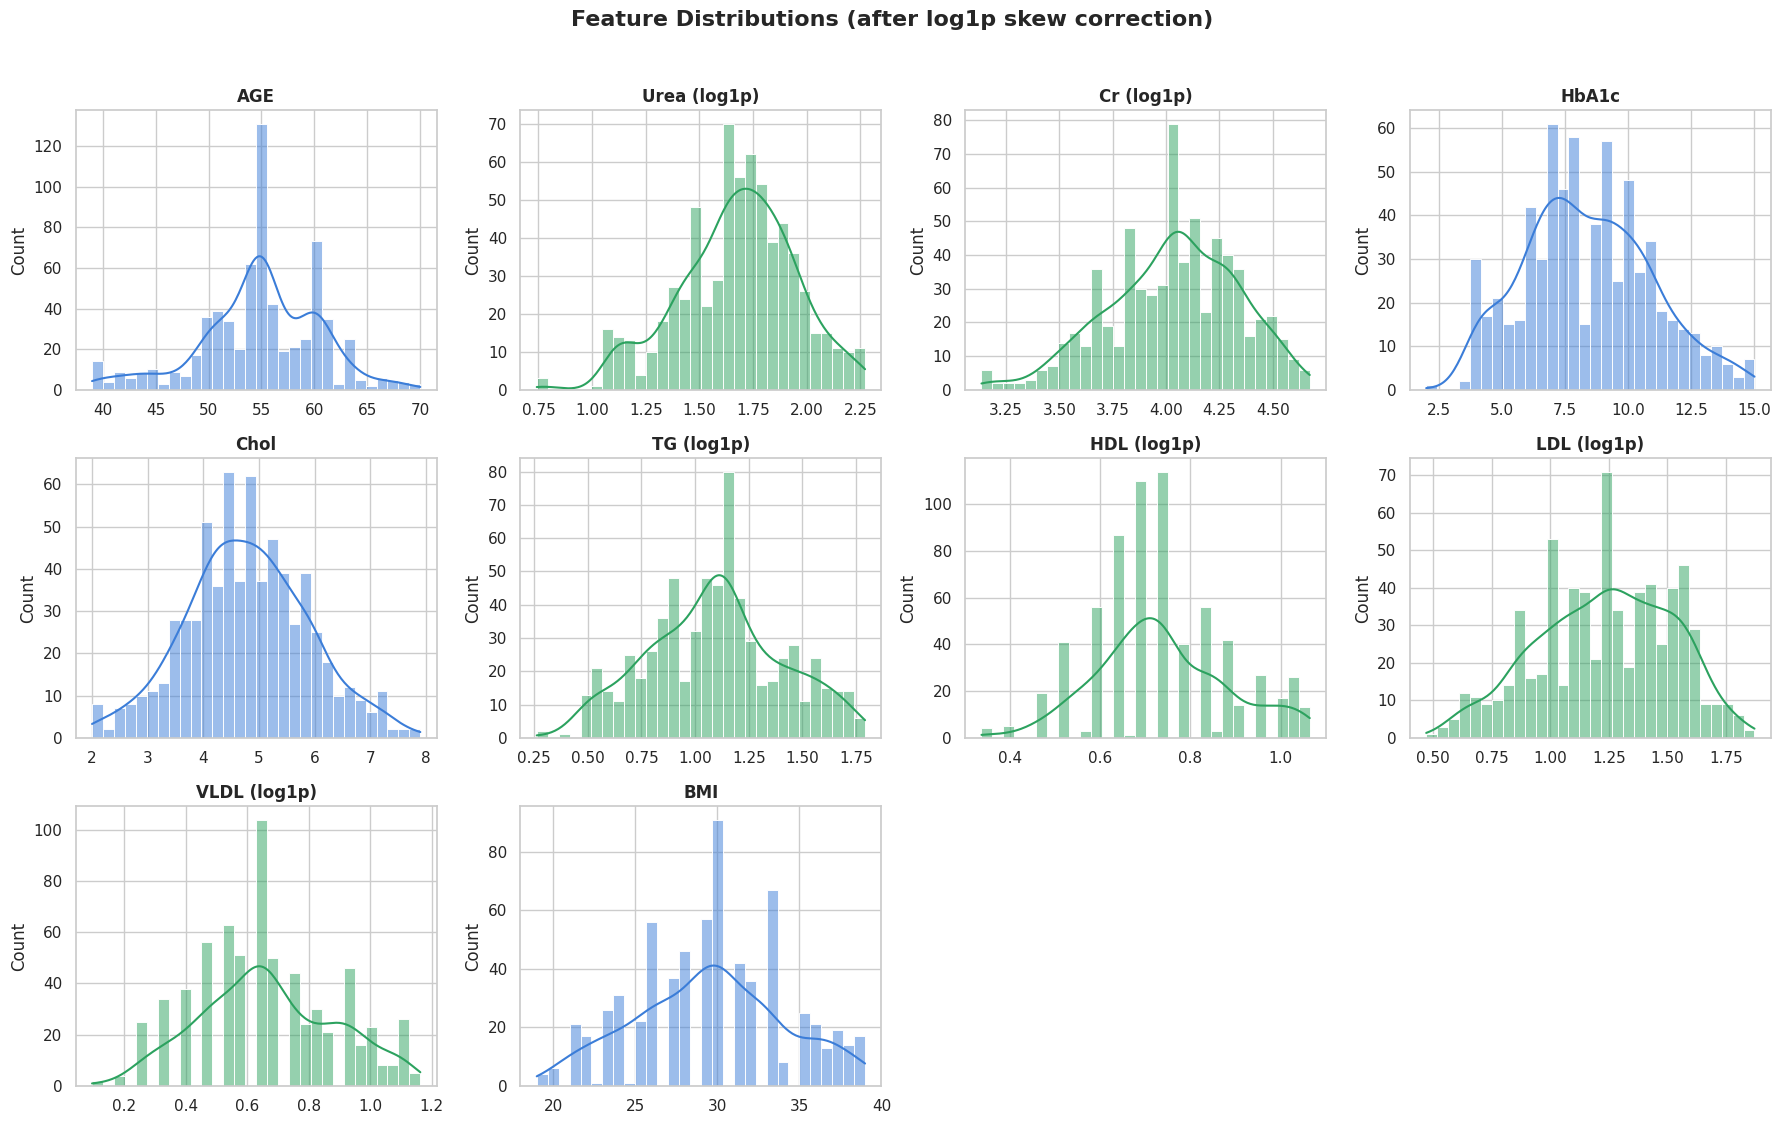

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [24]:
# # Fixing skewness
import numpy as np

skewed_columns = [ "VLDL" , "HDL" , "Urea", "Cr" , "LDL" , "TG"]
for column in skewed_columns:
    dataset[column] = np.log1p(dataset[column])
numerical_columns = dataset.select_dtypes(exclude="object")
numerical_columns = numerical_columns.drop(axis=1 , columns=["Gender" , "CLASS"])

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns.columns):
    is_transformed = col in skewed_columns
    color = "#2ca25f" if is_transformed else "#3b7dd8"
    sns.histplot(numerical_columns[col], bins=30, kde=True, color=color, ax=ax, edgecolor="white")
    ax.set_title(col + (" (log1p)" if is_transformed else ""), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
for ax in axes[len(numerical_columns.columns):]:
    ax.axis("off")
fig.suptitle("Feature Distributions (after log1p skew correction)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(dataset.isna().sum())

In [25]:
dataset.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0,45,1.193922,3.218876,4.0,2.9,0.693147,0.693147,0.916291,0.336472,21.0,0
6,0,50,1.098612,3.931826,4.0,3.6,0.832909,0.641854,1.131402,0.470004,24.0,0
7,1,48,1.740466,3.871201,4.0,2.9,0.587787,0.641854,0.955511,0.336472,24.0,0
13,0,45,1.722767,4.007333,5.1,4.2,0.993252,0.788457,1.163151,0.587787,23.0,0
14,0,50,1.504077,3.688879,4.0,4.0,0.916291,0.788457,1.163151,0.530628,24.0,0


In [26]:
#Divide our data into 3 groups
from scipy.stats import f_oneway

group_Y = dataset[dataset["CLASS"] == 1]
group_N = dataset[dataset["CLASS"] == 0]
group_P = dataset[dataset["CLASS"] == 2]
anovaColumns = ["AGE" , "Urea" , "Cr" , "HbA1c" ,"Chol" , "TG" , "HDL" , "LDL" , "VLDL" , "BMI" , "Gender"]
for column in anovaColumns:
    f_statistic, p_value = f_oneway(group_N[column] , group_P[column] , group_Y[column])
    print(f"Column : {column} , p_value : {p_value}")

#Any value lower than 0.05 means that this column can be used very well to diffrentiate between different target values => AGE , HbA1c , Chol , TG , VLDL , BMI, Urea ,Gender

Column : AGE , p_value : 7.577513666397487e-51
Column : Urea , p_value : 0.42528287538455734
Column : Cr , p_value : 0.6296991977575055
Column : HbA1c , p_value : 7.923968747656728e-47
Column : Chol , p_value : 0.00018709797229422926
Column : TG , p_value : 2.8951399027271677e-09
Column : HDL , p_value : 0.41218444625499007
Column : LDL , p_value : 0.3910836031248651
Column : VLDL , p_value : 7.391454000338725e-06
Column : BMI , p_value : 3.642215933896432e-58
Column : Gender , p_value : 0.008258291092678291


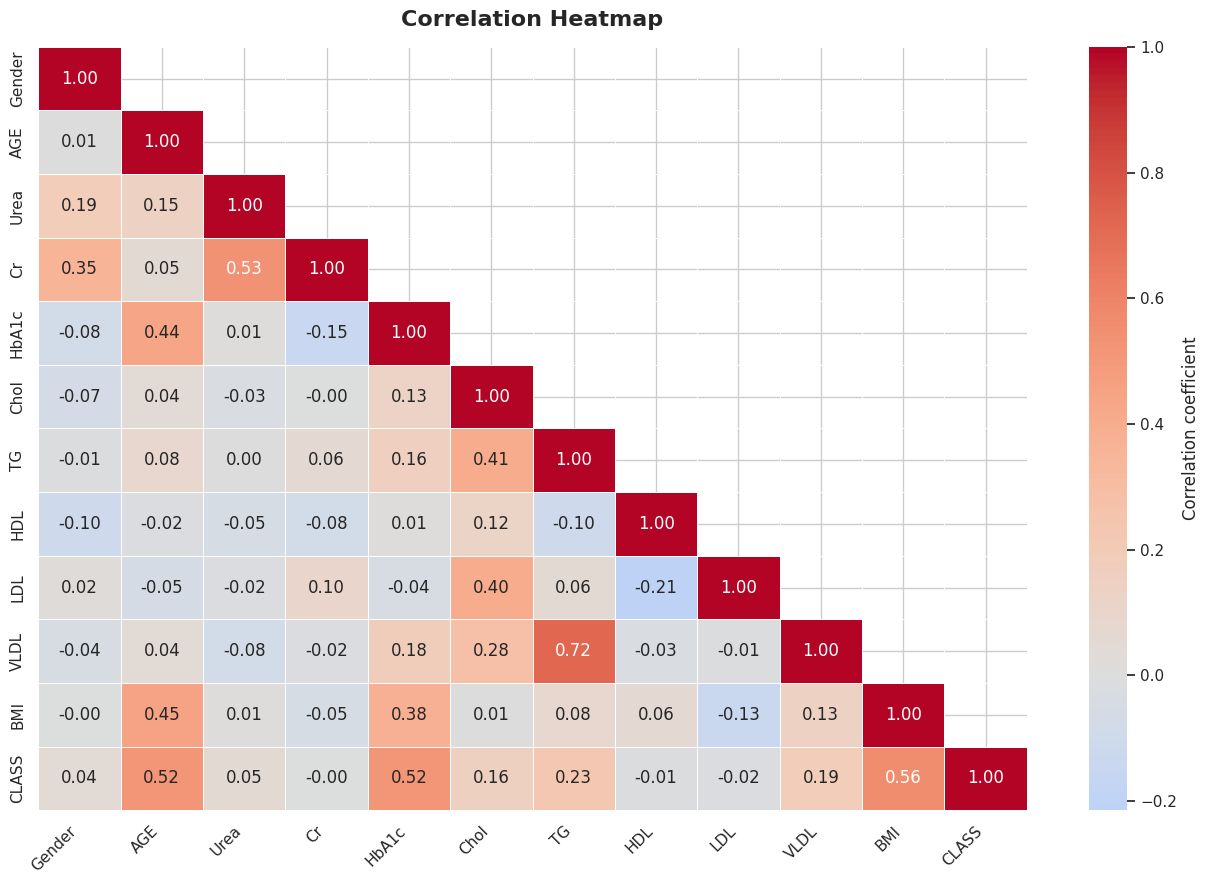

In [27]:
import seaborn as sns
import numpy as np

corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#Plotting the heatmap to display correlations and see if there is any multicolinearity
#Urea => CR

In [28]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np

def evaluate_bins(X, y, col, max_bins=10):
    results = {}
    for k in range(2, max_bins+1):
        disc = KBinsDiscretizer(n_bins=k, encode='ordinal', strategy='quantile')
        binned = disc.fit_transform(X[[col]])
        mi = mutual_info_classif(binned, y, discrete_features=True)
        results[k] = mi[0]
    return results


In [29]:
from sklearn.model_selection import train_test_split
import pandas as pd

x = dataset.drop(columns="CLASS", axis=1)
y = dataset["CLASS"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y,
)

x_train_s = x_train.copy()
y_train_s = y_train.copy()
x_test_s = x_test.copy()

print("Data split complete.")
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, sampling_strategy="auto")
x_train_s, y_train_s = sm.fit_resample(x_train_s, y_train_s)
x_train_s = pd.DataFrame(x_train_s, columns=x_train.columns)
y_train_s = pd.Series(y_train_s, name=y.name)

print("\nAfter SMOTE on continuous/log-transformed features:")
print(f"x_train_s shape: {x_train_s.shape}")
print(f"y_train_s distribution:\n{pd.Series(y_train_s).value_counts()}")

Data split complete.
x_train shape: (474, 11)
x_test shape: (204, 11)

After SMOTE on continuous/log-transformed features:
x_train_s shape: (1230, 11)
y_train_s distribution:
CLASS
2    410
1    410
0    410
Name: count, dtype: int64


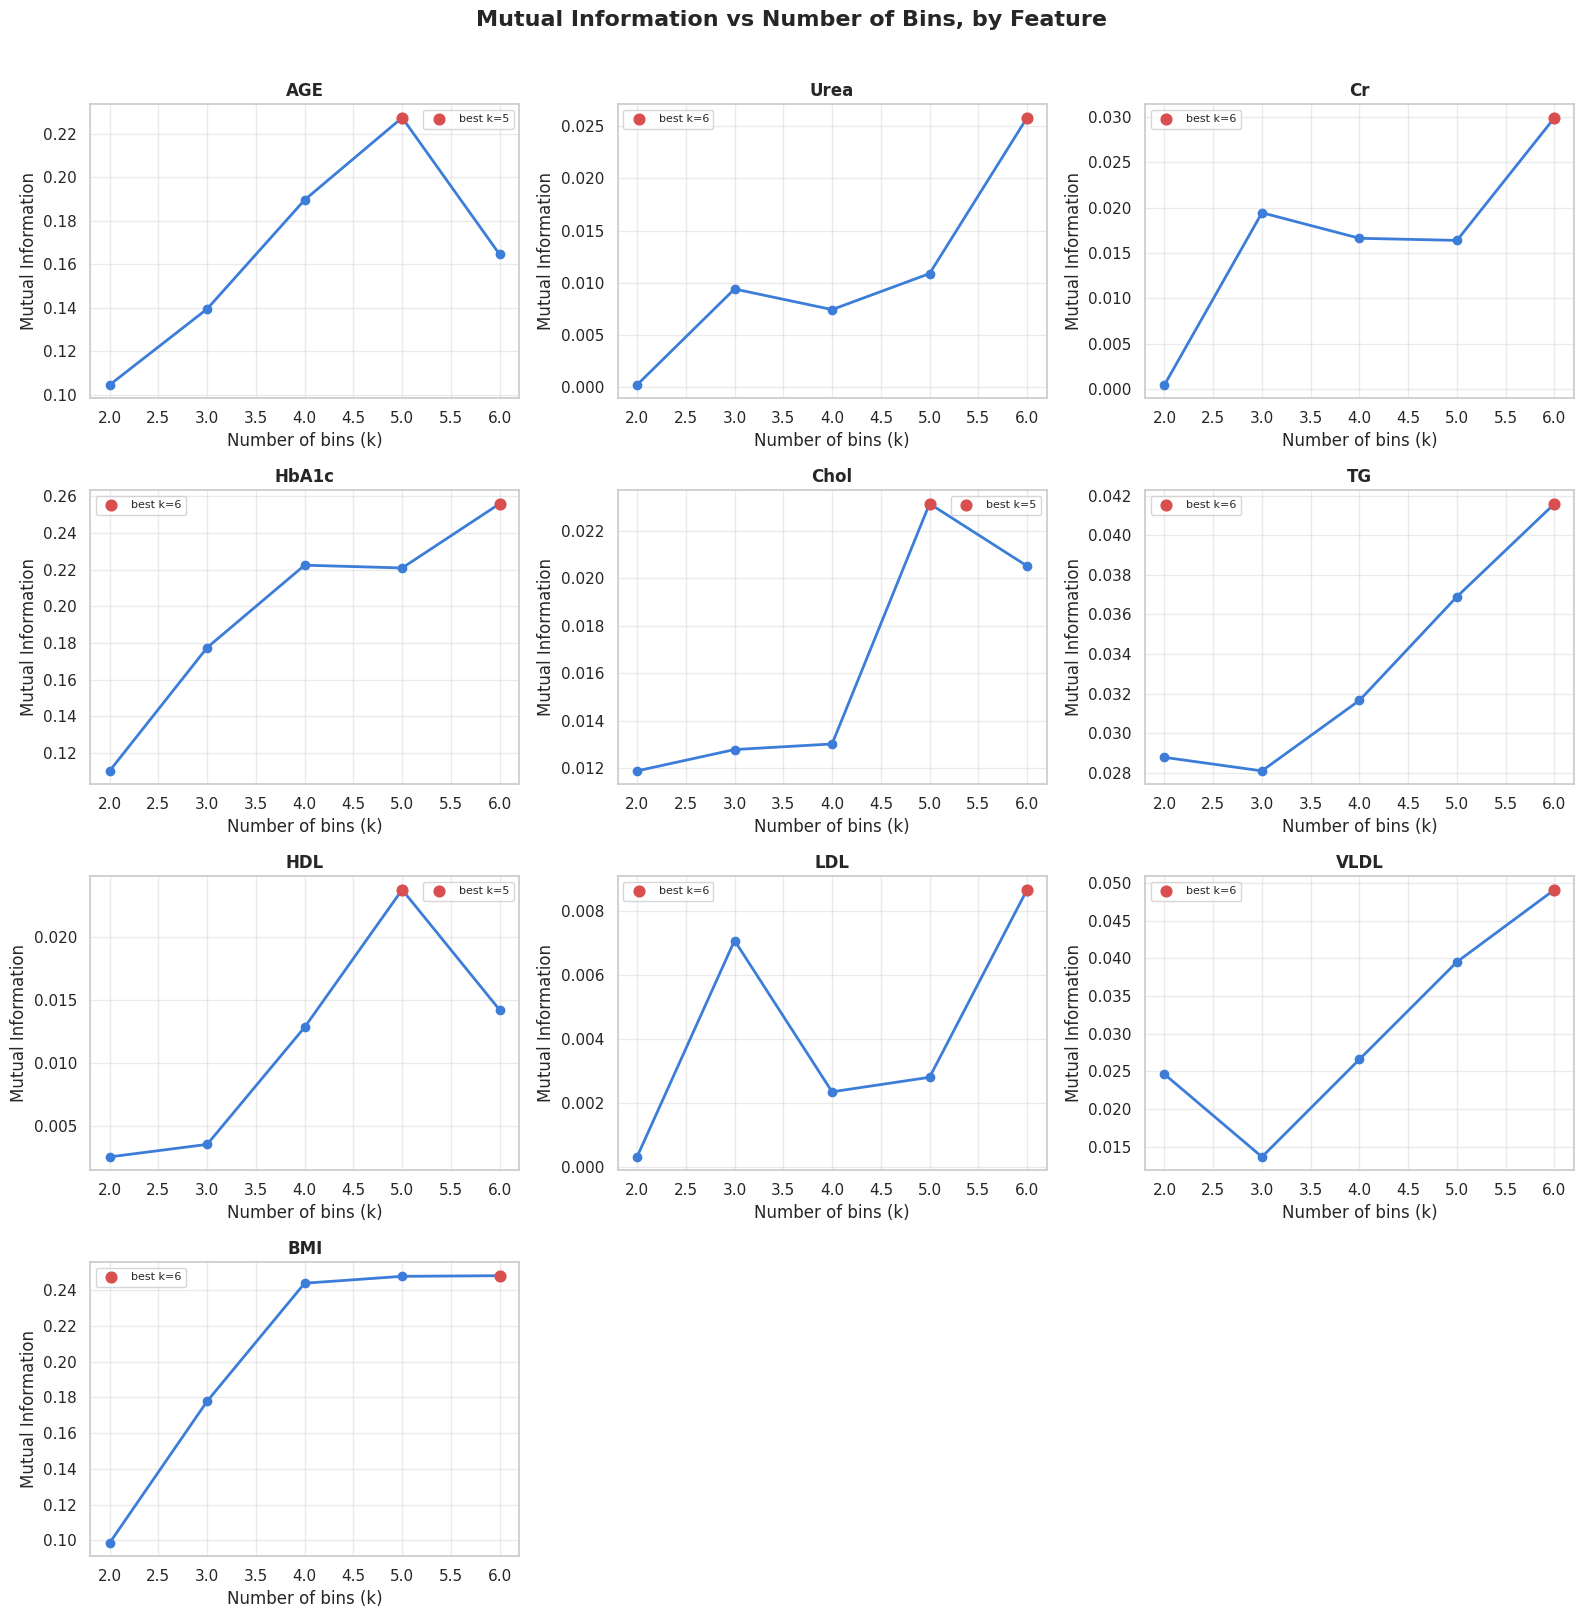

Best bins by feature:
{'AGE': 5, 'Urea': 6, 'Cr': 6, 'HbA1c': 6, 'Chol': 5, 'TG': 6, 'HDL': 5, 'LDL': 6, 'VLDL': 6, 'BMI': 6}


In [30]:
# Finding the best bin count on training data only to avoid data leakage.
datasetXTrain = x_train.copy()
features_to_bin = [col for col in datasetXTrain.columns if col != "Gender"]
resultsArr = []
best_bins_by_feature = {}

n_cols = len(features_to_bin)
n_rows = -(-n_cols // 3)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, features_to_bin):
    results = evaluate_bins(datasetXTrain, y_train, col, max_bins=6)
    resultsArr.append(results)

    best_k = max(results, key=results.get)
    best_bins_by_feature[col] = best_k

    ks = list(results.keys())
    mis = list(results.values())
    ax.plot(ks, mis, marker="o", color="#3b7dd8", linewidth=2)
    ax.scatter([best_k], [results[best_k]], color="#d94f4f", zorder=5, s=60, label=f"best k={best_k}")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of bins (k)")
    ax.set_ylabel("Mutual Information")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

for ax in axes[n_cols:]:
    ax.axis("off")

fig.suptitle("Mutual Information vs Number of Bins, by Feature", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Best bins by feature:")
print(best_bins_by_feature)

In [31]:
# Apply the selected bin count for each feature. Each column uses its own
# best_bins_by_feature value, fixing the phase-1 reuse of the last results object.
binners = {}
x_train_binned = x_train.copy()
x_test_binned = x_test.copy()

for col in features_to_bin:
    best_k = best_bins_by_feature[col]
    disc = KBinsDiscretizer(n_bins=best_k, encode="ordinal", strategy="quantile")
    x_train_binned[col] = disc.fit_transform(x_train_binned[[col]]).ravel().astype(int)
    x_test_binned[col] = disc.transform(x_test_binned[[col]]).ravel().astype(int)
    binners[col] = disc

x_train = x_train_binned
x_test = x_test_binned

print("Binned training data preview:")
display(x_train.head())

Binned training data preview:


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
444,1,2,5,3,4,3,4,1,0,4,4
306,0,3,3,2,2,0,2,3,1,2,1
304,0,3,4,1,4,4,4,1,5,4,5
539,0,4,5,1,1,0,4,0,0,4,2
391,0,2,2,1,2,3,3,2,4,3,2


In [32]:
from imblearn.over_sampling import SMOTEN

smoten = SMOTEN(random_state=42, sampling_strategy="auto")
x_train_s_bin, y_train_s_bin = smoten.fit_resample(x_train, y_train)
x_train_s_bin = pd.DataFrame(x_train_s_bin, columns=x_train.columns)
y_train_s_bin = pd.Series(y_train_s_bin, name=y.name)

print("\nAfter SMOTEN on binned features:")
print(f"x_train_s_bin shape: {x_train_s_bin.shape}")
print(f"y_train_s_bin distribution:\n{pd.Series(y_train_s_bin).value_counts()}")


After SMOTEN on binned features:
x_train_s_bin shape: (1230, 11)
y_train_s_bin distribution:
CLASS
2    410
1    410
0    410
Name: count, dtype: int64


In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

target_labels = [0, 1, 2]
target_names = ["Normal", "Pre-Diabetes", "Diabetes"]


def pipeline(x_train_input, y_train_input, x_test_input, y_test_input, featuresToUse=None, title="Decision Tree"):
    if featuresToUse is None:
        featuresToUse = list(x_train_input.columns)

    x_train_f = x_train_input[featuresToUse]
    x_test_f = x_test_input[featuresToUse]

    dt = DecisionTreeClassifier(
        random_state=42,
        criterion="entropy",
        max_depth=6,
        class_weight={0: 1, 1: 5, 2: 1},
    )

    dt.fit(x_train_f, y_train_input)

    print(f"\n=== {title}: Feature Importances Before Grid Search ===")
    for name, score in zip(featuresToUse, dt.feature_importances_):
        print(f"{name}: {score:.4f}")

    print(f"\n=== {title}: Baseline Model Performance ===")
    y_pred = dt.predict(x_test_f)
    print("Accuracy:", accuracy_score(y_test_input, y_pred))
    print("\nClassification Report:")
    print(
        classification_report(
            y_test_input,
            y_pred,
            labels=target_labels,
            target_names=target_names,
            zero_division=0,
        )
    )
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_input, y_pred, labels=target_labels))

    param_grid = {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": [3, 4, 5, 6],
        "class_weight": [
            {0: 1, 1: 5, 2: 1},
            {0: 1, 1: 3, 2: 1},
        ],
    }

    print(f"\n=== {title}: Running Grid Search ===")
    grid = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1,
    )

    grid.fit(x_train_f, y_train_input)

    print(f"\n=== {title}: Best Grid Search Results ===")
    print("Best Parameters:", grid.best_params_)
    print("Best Cross-Val Score:", grid.best_score_)

    best_model = grid.best_estimator_
    y_pred_best = best_model.predict(x_test_f)

    print(f"\n=== {title}: Final Model Performance After Grid Search ===")
    print("Accuracy:", accuracy_score(y_test_input, y_pred_best))
    print("\nClassification Report:")
    print(
        classification_report(
            y_test_input,
            y_pred_best,
            labels=target_labels,
            target_names=target_names,
            zero_division=0,
        )
    )
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_input, y_pred_best, labels=target_labels))

    plt.figure(figsize=(25, 15))
    plot_tree(
        best_model,
        feature_names=featuresToUse,
        class_names=target_names,
        filled=True,
        rounded=True,
        fontsize=8,
    )
    plt.title(f"{title} - Best Model")
    plt.show()

    return best_model


=== MI-Binned Decision Tree: Feature Importances Before Grid Search ===
AGE: 0.5168
HbA1c: 0.1739
Chol: 0.0848
TG: 0.0475
VLDL: 0.0509
BMI: 0.1054
Urea: 0.0111
Gender: 0.0096

=== MI-Binned Decision Tree: Baseline Model Performance ===
Accuracy: 0.9901960784313726

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        17
Pre-Diabetes       0.91      0.91      0.91        11
    Diabetes       0.99      0.99      0.99       176

    accuracy                           0.99       204
   macro avg       0.97      0.97      0.97       204
weighted avg       0.99      0.99      0.99       204


Confusion Matrix:
[[ 17   0   0]
 [  0  10   1]
 [  0   1 175]]

=== MI-Binned Decision Tree: Running Grid Search ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== MI-Binned Decision Tree: Best Grid Search Results ===
Best Parameters: {'class_weight': {0: 1, 1: 3, 2: 1}, 'criterion': 'entropy', 'max_depth'

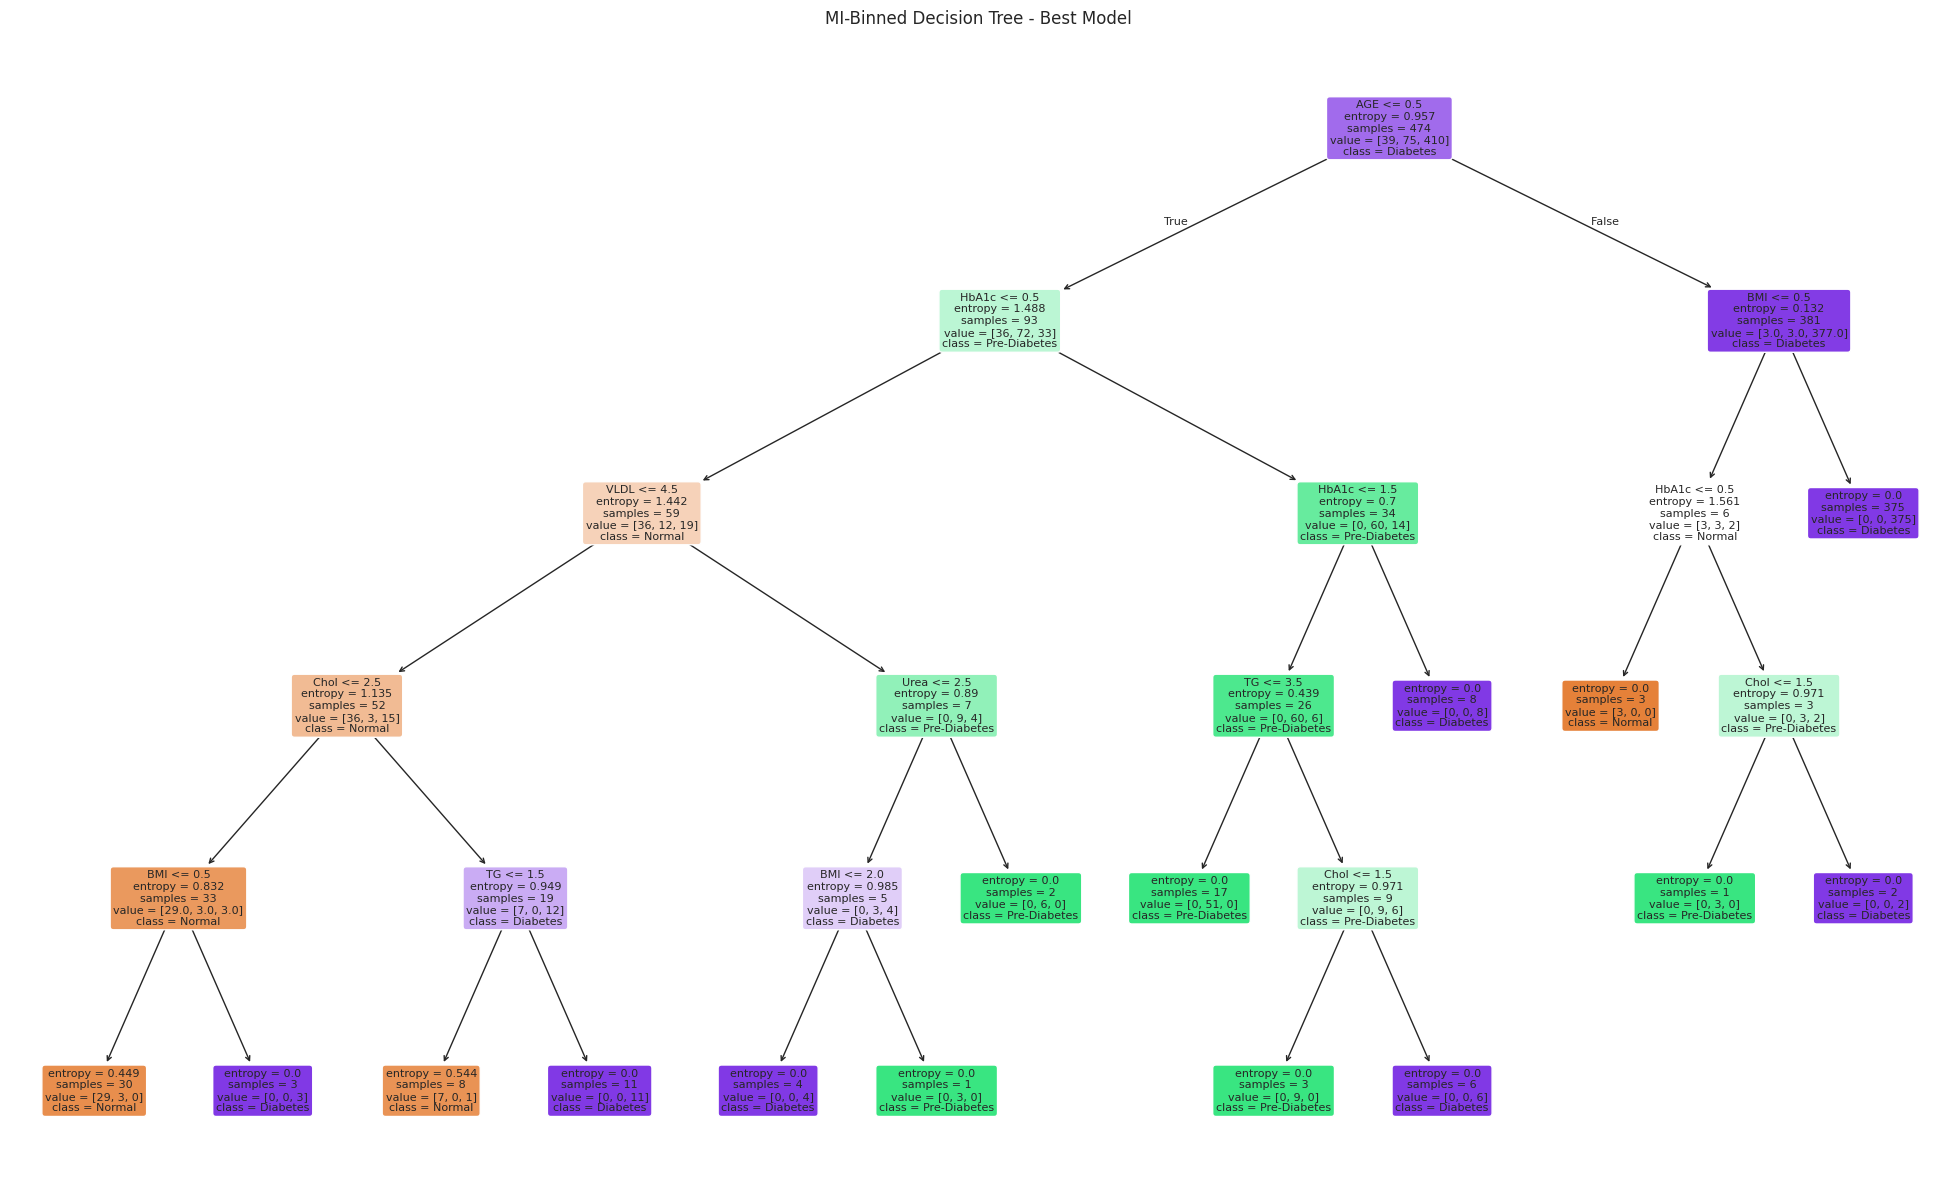

In [34]:
featuresToUse = ["AGE", "HbA1c", "Chol", "TG", "VLDL", "BMI", "Urea", "Gender"]
best_model_binned = pipeline(
    x_train,
    y_train,
    x_test,
    y_test,
    featuresToUse,
    title="MI-Binned Decision Tree",
)


=== Continuous SMOTE Decision Tree: Feature Importances Before Grid Search ===
AGE: 0.0306
HbA1c: 0.9076
Chol: 0.0091
TG: 0.0147
VLDL: 0.0006
BMI: 0.0374
Urea: 0.0000
Gender: 0.0000

=== Continuous SMOTE Decision Tree: Baseline Model Performance ===
Accuracy: 0.9852941176470589

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94        17
Pre-Diabetes       1.00      0.91      0.95        11
    Diabetes       0.99      0.99      0.99       176

    accuracy                           0.99       204
   macro avg       0.98      0.95      0.96       204
weighted avg       0.99      0.99      0.99       204


Confusion Matrix:
[[ 16   0   1]
 [  0  10   1]
 [  1   0 175]]

=== Continuous SMOTE Decision Tree: Running Grid Search ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Continuous SMOTE Decision Tree: Best Grid Search Results ===
Best Parameters: {'class_weight': {0: 1, 1: 5, 2: 1}, 'criter

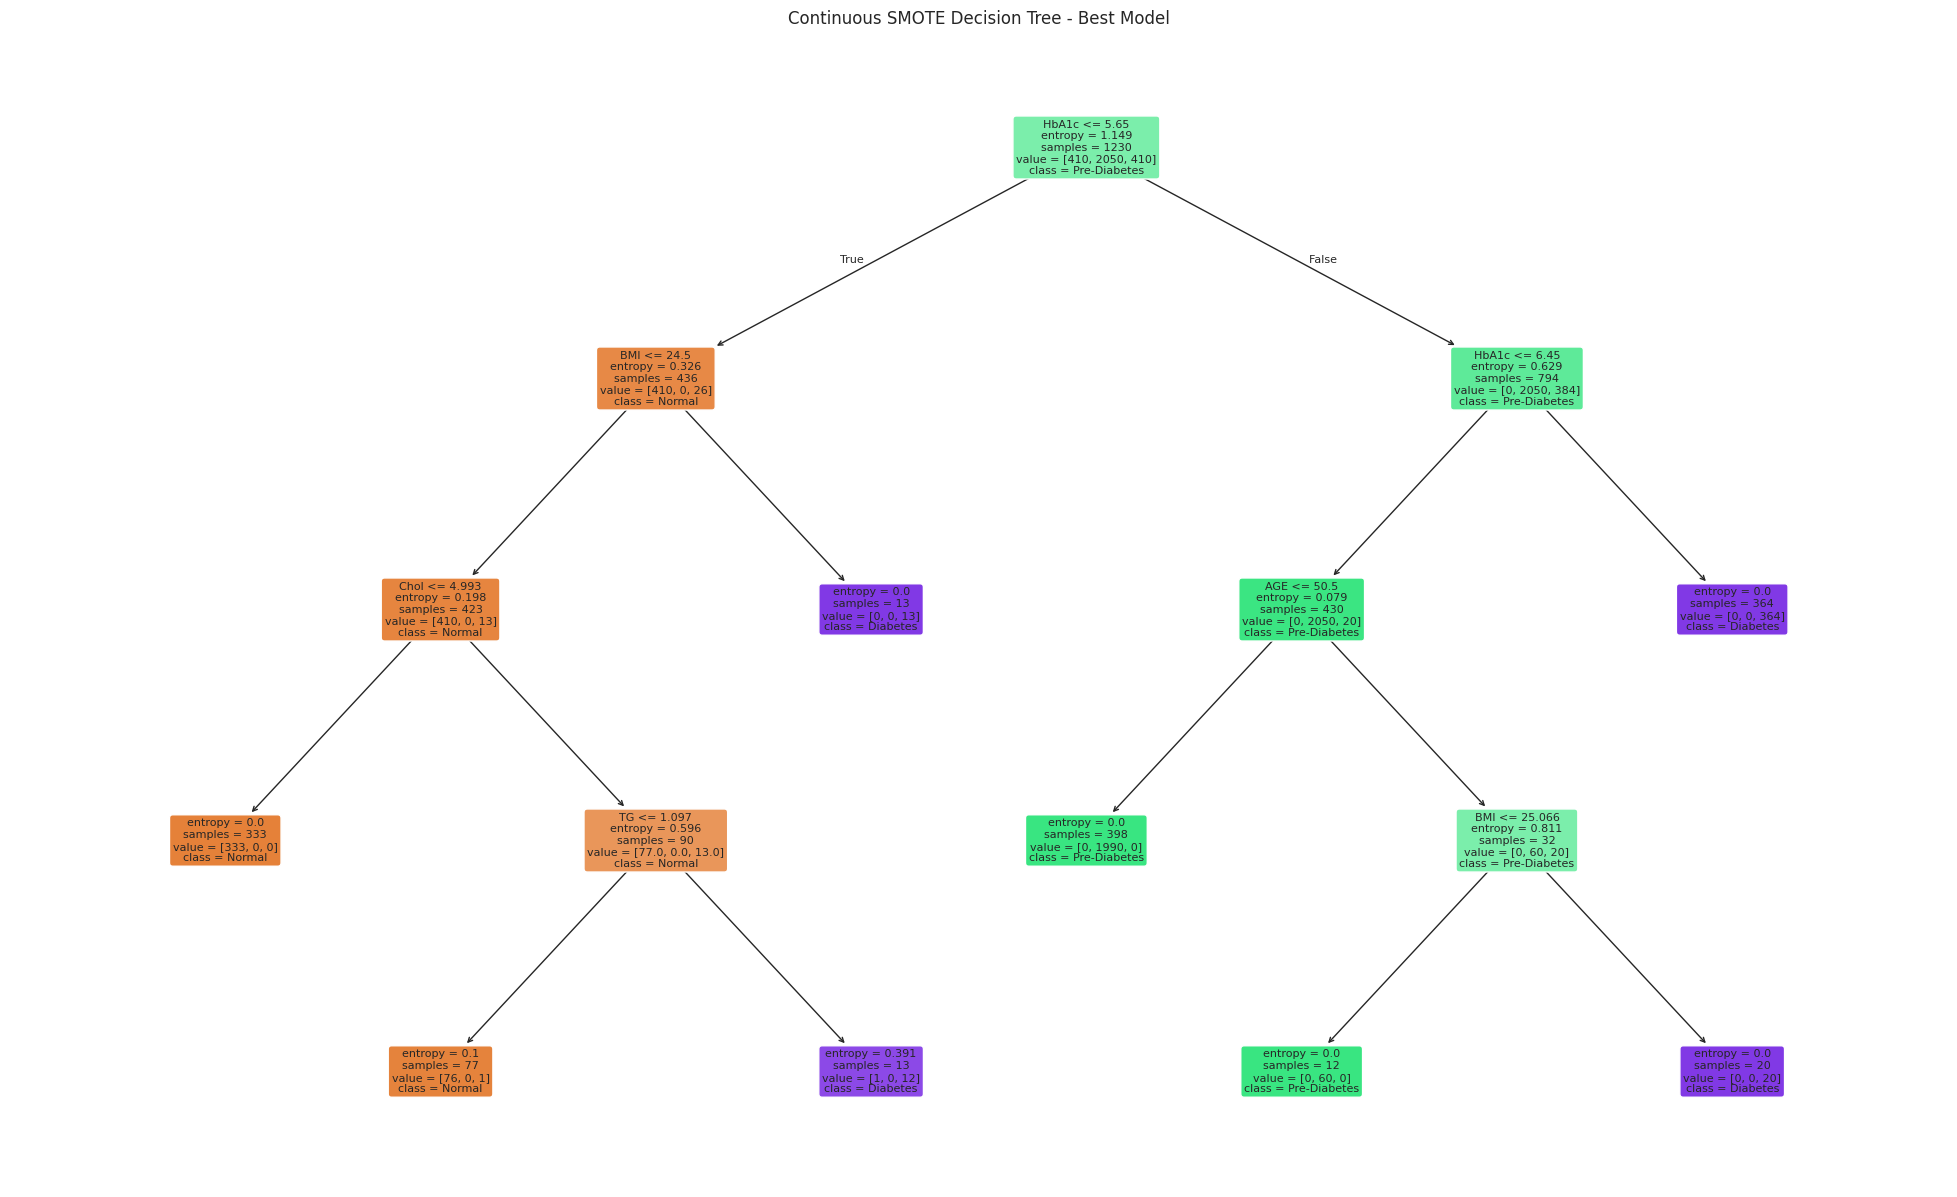

In [35]:
featuresToUse = ["AGE", "HbA1c", "Chol", "TG", "VLDL", "BMI", "Urea", "Gender"]
best_model_smote = pipeline(
    x_train_s,
    y_train_s,
    x_test_s,
    y_test,
    featuresToUse,
    title="Continuous SMOTE Decision Tree",
)